# 24-788 Project: GNNs for QM9 Molecular Properties
This notebook implements the GCN Baseline model. It covers data loading, normalization, model definition, training, and evaluation.

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00


## 1. Data Loading and Preprocessing
We use the QM9 dataset and normalize the `HOMO-LUMO gap` (target index 4). We also perform a standard 110k/10k/10k split.

In [ ]:
import torch
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader

TARGET_IDX = 4  # HOMO-LUMO gap

#load dataset
dataset = QM9(root='./data/QM9')

# Normalization
all_targets = dataset.data.y[:, TARGET_IDX]
TARGET_MEAN = all_targets.mean().item()
TARGET_STD  = all_targets.std().item()

# Normalize target in place
dataset.data.y[:, TARGET_IDX] = (dataset.data.y[:, TARGET_IDX] - TARGET_MEAN) / TARGET_STD

# Train/Val/Test
torch.manual_seed(42)
train_dataset = dataset[:110000]
val_dataset   = dataset[110000:120000]
test_dataset  = dataset[120000:130000]

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Data Loaded. Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Extracting data/QM9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Data Loaded. Train: 110000, Val: 10000, Test: 10000


/tmp/ipykernel_31903/2264021251.py:11: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  all_targets = dataset.data.y[:, TARGET_IDX]
/tmp/ipykernel_31903/2264021251.py:16: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  dataset.data.y[:, TARGET_IDX] = (dataset.data.y[:, TARGET_IDX] - TARGET_MEAN) / TARGET_STD


## 2. Model Definition (GCN Baseline)
The GCN Baseline uses only graph connectivity and node features, ignoring 3D positions.

In [ ]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

class GCNBaseline(nn.Module):
    def __init__(self, in_channels=11, hidden_channels=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.mlp = nn.Sequential(nn.Linear(hidden_channels, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index).relu()
            x = bn(x)
        x = global_mean_pool(x, batch)
        return self.mlp(x).squeeze(-1)

Using device: cpu


## 3. Training and Evaluation

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred   = model(batch)
        target = batch.y[:, TARGET_IDX]
        loss   = nn.functional.mse_loss(pred, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_mae = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        pred   = model(batch) * TARGET_STD + TARGET_MEAN
        target = batch.y[:, TARGET_IDX] * TARGET_STD + TARGET_MEAN
        total_mae += (pred - target).abs().sum().item()
    return total_mae / len(loader.dataset)

## 4. Training the GCN

In [ ]:
def train_model(model, model_name, num_epochs=100):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    history = {'train_loss': [], 'val_mae': []}
    best_val_mae = float('inf')

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_mae    = evaluate(model, val_loader)
        scheduler.step(val_mae)
        history['train_loss'].append(train_loss)
        history['val_mae'].append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), f'best_{model_name}.pt')

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | Val MAE: {val_mae*1000:.1f} meV")

    return history, best_val_mae

gcn_model = GCNBaseline()
history, best_val = train_model(gcn_model, 'GCN', num_epochs=100)

Epoch  10 | Loss: 0.0770 | Val MAE: 229.7 meV
Epoch  20 | Loss: 0.0653 | Val MAE: 205.0 meV
Epoch  30 | Loss: 0.0579 | Val MAE: 220.5 meV
Epoch  40 | Loss: 0.0540 | Val MAE: 198.1 meV
Epoch  50 | Loss: 0.0512 | Val MAE: 194.9 meV
Epoch  60 | Loss: 0.0510 | Val MAE: 193.0 meV
Epoch  70 | Loss: 0.0453 | Val MAE: 189.5 meV
Epoch  80 | Loss: 0.0445 | Val MAE: 176.2 meV
Epoch  90 | Loss: 0.0424 | Val MAE: 171.4 meV
Epoch 100 | Loss: 0.0422 | Val MAE: 172.7 meV


## 5. Test Results
Load the best checkpoint and evaluate on the test set.

In [10]:
gcn_model.load_state_dict(torch.load('best_GCN.pt'))
test_mae = evaluate(gcn_model, test_loader)
print(f"Final GCN Test MAE: {test_mae*1000:.1f} meV")

Final GCN Test MAE: 300.3 meV


## 6. Visualization
Plotting the training loss and validation MAE curves.

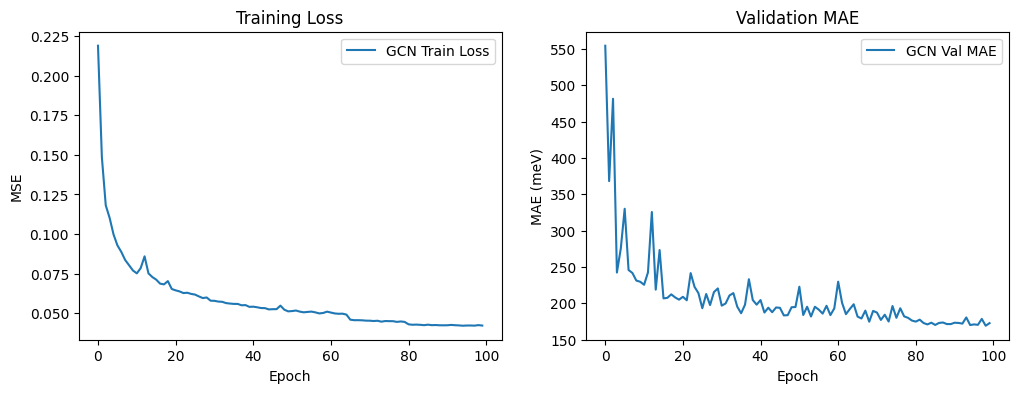

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='GCN Train Loss')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.legend()

ax2.plot([m*1000 for m in history['val_mae']], label='GCN Val MAE')
ax2.set_title('Validation MAE'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE (meV)'); ax2.legend()
plt.show()

In [ ]:
model = GCNBaseline()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"GCN total parameters: {total_params:,}")

GCN total parameters: 11,585
